In [1]:
import pandas as pd
import torch

In [5]:
df = pd.read_parquet('finaly_dataset.parquet', engine='fastparquet')

In [3]:
# df.describe()

In [4]:
# df_drop = df.drop(['repo', 'path', 'language', 'sha', 'url', 'partition'], axis=1)

In [5]:
# df_drop.info()

In [2]:
def reduce_dataset_size(dataset, fraction=0.1, seed=42):
    """Сокращает датасет до указанной доли"""
    size = int(len(dataset) * fraction)
    return dataset.shuffle(seed=seed).select(range(size))

In [11]:
df = reduce_dataset_size(df)

AttributeError: 'DataFrame' object has no attribute 'select'

In [2]:
from datasets import load_dataset, DatasetDict
import os

c:\Project\torch\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def load_local_dataset(data_path: str):
    """
    Загружает локальный датасет в формате json/jsonl/csv/parquet.
    """
    ext = os.path.splitext(data_path)[1]
    if ext == ".json":
        ds = load_dataset("json", data_files=data_path, split="train")
    elif ext in [".jsonl", ".jl"]:
        ds = load_dataset("json", data_files=data_path, split="train")
    elif ext == ".csv":
        ds = load_dataset("csv", data_files=data_path, split="train")
    elif ext == ".parquet":
        ds = load_dataset("parquet", data_files=data_path, split="train")
    else:
        raise ValueError(f"Неподдерживаемый формат: {ext}")
    return ds

In [4]:
from datasets import Dataset
df = pd.read_parquet("git_dataset.parquet")
ds = Dataset.from_pandas(df)

In [11]:
def load_and_filter(data_path: str):
    print(f"🔹 Загружаем локальный датасет из {data_path}")
    ds = load_local_dataset(data_path)


    # df = pd.read_parquet("finaly_dataset.parquet")
    # ds = Dataset.from_pandas(df)

    
    # ds = reduce_dataset_size(ds, fraction=0.1)

    print(f"✅ Загружено {len(ds)} примеров. Фильтруем...")

    def keep(ex):
        code = ex.get("code", "")
        docstring = ex.get("docstring", "")
        if not code or not docstring:
            return False
        if len(code.split()) > 400:
            return False
        if len(docstring.split()) > 128:
            return False
        return True

    ds = ds.filter(keep)
    ds = ds.shuffle(seed=42)

    n = len(ds)
    n_train = int(n * 0.8)
    n_valid = int(n * 0.1)
    n_test = n - n_train - n_valid

    ds_train = ds.select(range(0, n_train))
    ds_valid = ds.select(range(n_train, n_train + n_valid))
    ds_test = ds.select(range(n_train + n_valid, n))

    dataset = DatasetDict({
        "train": ds_train,
        "validation": ds_valid,
        "test": ds_test
    })

    print(f"✅ После фильтрации осталось {len(ds)} примеров.")
    print(f"📊 Разделение: train={len(ds_train)}, valid={len(ds_valid)}, test={len(ds_test)}")

    return dataset

In [6]:
import os

In [12]:
if __name__ == "__main__":
    # Укажи путь к файлу вручную
    DATA_PATH = "git_dataset.parquet" 

    dataset = load_and_filter(DATA_PATH)
    dataset.save_to_disk("csn_python_filtered")
    ds = dataset
    print("💾 Датасет сохранён в 'csn_python_filtered'")

🔹 Загружаем локальный датасет из git_dataset.parquet
✅ Загружено 18570 примеров. Фильтруем...


Filter: 100%|██████████| 18570/18570 [00:00<00:00, 147496.58 examples/s]


✅ После фильтрации осталось 17407 примеров.
📊 Разделение: train=13925, valid=1740, test=1742


Saving the dataset (1/1 shards): 100%|██████████| 1742/1742 [00:00<00:00, 182972.99 examples/s]

💾 Датасет сохранён в 'csn_python_filtered'


In [13]:
from transformers import T5Config

def get_config():
    config = T5Config(
        vocab_size=32128,      # будет обновлен под токенизатор (resize later)
        d_model=256,           # скрытый размер (embedding)
        d_ff=1024,             # размер FFN (обычно 3-4*d_model)
        num_layers=4,          # encoder layers
        num_decoder_layers=4,  # decoder layers
        num_heads=4,
        dropout_rate=0.1,
        relative_attention_bias=True,
    )
    return config

In [14]:
import os
from datasets import load_from_disk
from transformers import (
    T5ForConditionalGeneration, T5Config, AutoTokenizer,
    DataCollatorForSeq2Seq, TrainingArguments, Trainer,
    T5TokenizerFast
)


In [15]:
def preprocess(batch, tokenizer, max_src_len=256, max_tgt_len=64):
    inputs = batch["code"]
    targets = batch["docstring"]  # summary или docstring
    model_inputs = tokenizer(inputs, max_length=max_src_len, truncation=True, padding="max_length")
    labels = tokenizer(targets, max_length=max_tgt_len, truncation=True, padding="max_length")
    # replace pad token id's in labels by -100
    labels_ids = labels["input_ids"]
    labels_ids = [[(tok if tok != tokenizer.pad_token_id else -100) for tok in l] for l in labels_ids]
    model_inputs["labels"] = labels_ids
    return model_inputs

In [16]:
# metrics_eval.py
import evaluate
import numpy as np

# Загружаем метрики
bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")

def postprocess_text(preds, labels):
    preds = [p.strip() for p in preds]
    labels = [[l.strip()] for l in labels]  # BLEU требует список списков
    return preds, labels

def compute_metrics(eval_preds, tokenizer):
    preds, labels = eval_preds
    if isinstance(preds, tuple):
        preds = preds[0]

    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds, decoded_labels = postprocess_text(decoded_preds, decoded_labels)

    # вычисляем метрики
    bleu_result = bleu.compute(predictions=decoded_preds, references=decoded_labels)
    rouge_result = rouge.compute(predictions=decoded_preds, references=decoded_labels)

    # если новая версия evaluate (без mid)
    if isinstance(rouge_result["rouge1"], float) or isinstance(rouge_result["rouge1"], np.float64):
        result = {
            "bleu": bleu_result["bleu"],
            "rouge1": rouge_result["rouge1"],
            "rougeL": rouge_result["rougeL"],
        }
    else:
        result = {
            "bleu": bleu_result["bleu"],
            "rouge1": rouge_result["rouge1"].mid.fmeasure,
            "rougeL": rouge_result["rougeL"].mid.fmeasure,
        }

    result = {k: round(float(v) * 100, 2) for k, v in result.items()}
    return result



In [18]:
def main():
    # 1) загрузим данные, подготовленные ранее
    # ds = load_from_disk("csn_python_filtered")
    # tokenizer = AutoTokenizer.from_pretrained("Salesforce/codet5-small")
    tokenizer = T5TokenizerFast.from_pretrained("t5-small")

    # 2) создаём конфиг и модель с нуля
    config = get_config()
    # чтобы vocab совпадал с токенизатором, переопределим vocab_size
    config.vocab_size = len(tokenizer)
    model = T5ForConditionalGeneration(config)

    # ДОБАВЬТЕ ЭТУ СТРОКУ:
    model.config.decoder_start_token_id = tokenizer.pad_token_id


    # resize token embeddings под используемый токенизатор
    model.resize_token_embeddings(len(tokenizer))

    # 3) подготовка датасетов (map + remove original columns)
    ds_tokenized = ds.map(lambda examples: preprocess(examples, tokenizer), batched=True, remove_columns=ds["train"].column_names)

    # коллатор
    data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model, return_tensors="pt")

    # 4) training args
    training_args = TrainingArguments(
        output_dir="./m1",
        num_train_epochs=6,
        per_device_train_batch_size=8,   # подстраивай под VRAM
        per_device_eval_batch_size=8,
        gradient_accumulation_steps=2,   # если VRAM мал — увеличь
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=5e-4,   # чуть выше для обучения с нуля
        warmup_steps=500,
        weight_decay=0.01,
        logging_steps=200,
        fp16=False,
        save_total_limit=3,
        push_to_hub=False,
        report_to=["tensorboard"],  # для графиков
        load_best_model_at_end=True,
    )

    trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds_tokenized["train"],
    eval_dataset=ds_tokenized["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=lambda eval_pred: compute_metrics(eval_pred, tokenizer),
    )

    trainer.train()
    trainer.save_model("./m1")
    tokenizer.save_pretrained("./m1")

In [19]:
if __name__ == "__main__":
    main()

Map: 100%|██████████| 1742/1742 [00:00<00:00, 5884.87 examples/s]
c:\Project\torch\.venv\lib\site-packages\transformers\optimization.py:306: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
***** Running training *****
  Num examples = 13925
  Num Epochs = 6
  Instantaneous batch size per device = 8
  Total train batch size (w. parallel, distributed & accumulation) = 16
  Gradient Accumulation steps = 2
  Total optimization steps = 5220
  0%|          | 0/5220 [00:00<?, ?it/s]c:\Project\torch\.venv\lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
  2%|▏         | 97/5220 [02:16<1:58:28,  1.39s/it]

KeyboardInterrupt: 

In [26]:
# eval_inference.py
from transformers import AutoTokenizer, T5ForConditionalGeneration

tokenizer = AutoTokenizer.from_pretrained("./scratch_t5_model")
model = T5ForConditionalGeneration.from_pretrained("./scratch_t5_model")

def generate(code_snippet):
    inputs = tokenizer(code_snippet, return_tensors="pt", truncation=True, max_length=256)
    outputs = model.generate(
        inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_length=64,
        num_beams=5,
        early_stopping=True,
        no_repeat_ngram_size=3
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

if __name__ == "__main__":
    sample = "def add(a, b):\n    return a + b"
    print(generate(sample))


Check if a string.


In [48]:
import torch
from transformers import T5ForConditionalGeneration, AutoTokenizer
from datasets import load_from_disk

# Загружаем модель и токенизатор
model_dir = "./scratch_t5_model"
tokenizer = AutoTokenizer.from_pretrained(model_dir)
model = T5ForConditionalGeneration.from_pretrained(model_dir)
model.eval()

# Загружаем тестовый датасет
ds = load_from_disk("csn_python_filtered")
test_ds = ds["test"]

# Берём подмножество
subset = test_ds.select(range(100))

# Приводим код к строкам
def ensure_text(x):
    if isinstance(x, list):
        # если это список токенов — склеим обратно
        return " ".join(x)
    elif isinstance(x, str):
        return x
    else:
        return ""

codes = [ensure_text(c) for c in subset["code"]]

# Убираем пустые
filtered = [(c, s) for c, s in zip(codes, subset["summary"]) if c and s]
codes, refs = zip(*filtered)

# Токенизация
inputs = tokenizer(list(codes), padding=True, truncation=True, max_length=256, return_tensors="pt")

# Генерация
with torch.no_grad():
    preds = model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_length=64,
        num_beams=5
    )

# Оценка метрик
metrics = compute_metrics((preds, tokenizer(list(refs), padding=True, truncation=True, max_length=64, return_tensors="pt")["input_ids"]), tokenizer)
print("📊 Metrics:", metrics)


📊 Metrics: {'bleu': 1.29, 'rouge1': 15.58, 'rougeL': 14.53}


Index(['epoch', 'learning_rate', 'loss', 'step', 'eval_bleu', 'eval_loss',
       'eval_rouge1', 'eval_rougeL', 'eval_runtime', 'eval_samples_per_second',
       'eval_steps_per_second'],
      dtype='object')


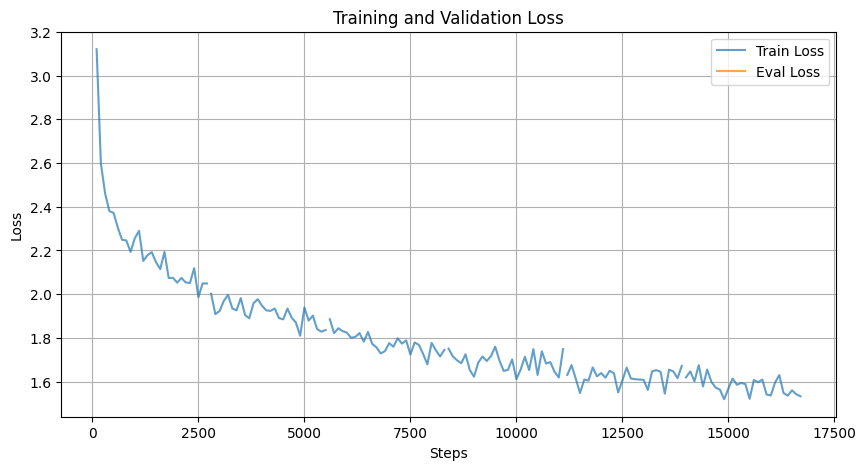

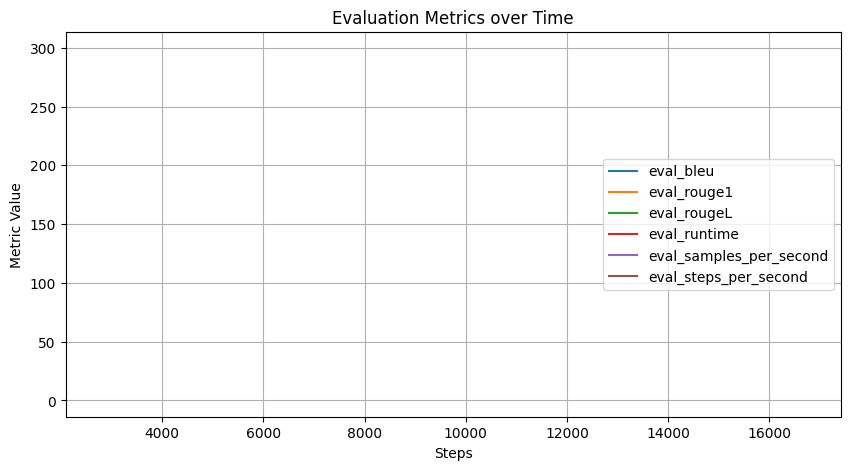

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# Загружаем trainer_state.json как обычный JSON
with open("git_results/checkpoint-16716/trainer_state.json", "r") as f:
    data = json.load(f)

# Извлекаем лог истории
logs = data["log_history"]

# Преобразуем в DataFrame
df = pd.DataFrame(logs)

# Смотрим, какие поля есть
print(df.columns)

# Строим графики
plt.figure(figsize=(10, 5))
plt.plot(df["step"], df["loss"], label="Train Loss", alpha=0.7)
if "eval_loss" in df.columns:
    plt.plot(df["step"], df["eval_loss"], label="Eval Loss", alpha=0.7)

plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Если есть метрики (например, BLEU или ROUGE)
metric_cols = [col for col in df.columns if col.startswith("eval_") and col not in ["eval_loss"]]
if metric_cols:
    plt.figure(figsize=(10, 5))
    for col in metric_cols:
        plt.plot(df["step"], df[col], label=col)
    plt.xlabel("Steps")
    plt.ylabel("Metric Value")
    plt.title("Evaluation Metrics over Time")
    plt.legend()
    plt.grid(True)
    plt.show()


In [31]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


False


AssertionError: Torch not compiled with CUDA enabled

In [2]:
import torch
print(torch.__version__)
print(torch.version.cuda)


1.10.2
None


In [2]:
from transformers import T5Tokenizer

# Укажите имя предобученной модели, которую вы использовали как основу
# Например: "t5-small", "t5-base", "t5-large" и т.д.
base_model_name = "t5-small"  

# Путь к папке вашей модели (используйте сырые строки или прямые слеши)
model_folder = "C:/Project/codet5-docstring/codet5-docstring/ml_server/model/git_model"

# Загружаем токенизатор из предобученной модели
tokenizer = T5Tokenizer.from_pretrained(base_model_name)

# Сохраняем токенизатор в папку с моделью
tokenizer.save_pretrained(model_folder)

print("Токенизатор успешно сохранён в", model_folder)

Токенизатор успешно сохранён в C:/Project/codet5-docstring/codet5-docstring/ml_server/model/git_model
